#### EDA (Exploratory Data Analysis)

1. Load datasets
2. Clean data (missing values,duplicates,types)
3. Treat outliers
4. Univariate and bivariate and multivariate analysis
5. insights

##### Outlier- a data point that is significantly different from other observations in a dataset.

How outliers will come---?
1. Measurement errors
2. Data entry mistakes

Why they are important---?
1. They can be errors
2. They effect the data analysis

How to identify the outliers....?
1. Statistical methods

---> Interquartile Range (IQR)

---> Z-Score

2. Visualization Techniques
---> Box Plots

---> Scatter Plots

---> Histograms


Univariate analysis--a method that analyzes a single variable to describe its characteristics and finding patterns and summarize the data.

It involves only one variable.
 
Bi variate analysis-it will give relationship between 2 variables.It helps to find if there is any co-relation ,association or connection between the 2 variables 

It involves 2 variables (x & y)

Multivariate analysis-To understand how multiple factors interact and influence with each other

It involves more than 2  

Example-

How our age,income,and education level together influence the purchasing behaviour.

### ETL

## EDA : <Dataset>

1. Load &overview

2. Cleaning (missing,dupes,dtypes)

3. Uni , Bi & multi analysis

4. Outlier -IQR

5. Feature Engineering 

6. Key Insights

Feature Engineering - " F.E is the process of turning raw data into useful features" that helps to improve the performance of machine learning models.

1. Load libraries and dataset

In [3]:
import pandas as pd
import numpy as numpy
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# Load the titanic dataset from seaborn 
df = sns.load_dataset('titanic')
df.head()
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [8]:
#Basic information and overview of the dataset 
print("Shape of the dataset:",df.shape)
print("\n Info about the dataset ;\n")
df.info()
#Summary Statistics 
df.describe(include='all')



Shape of the dataset: (891, 14)

 Info about the dataset ;

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  embark_town  889 non-null    object  
 12  alive        891 non-null    object  
 13  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 79.4+ KB


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
count,891.000000,891.000000,891,891.000000,891.000000,891.000000,891.000000,891,891,891,891,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,646,491,537,537,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,13.002015,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,22.000000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,29.699118,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,35.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
#Missing values analysis 

missing=pd.DataFrame({
    'missing_count':df.isnull().sum(),
    'missing_percent':(df.isnull().sum()/ len(df)) * 100
})

missing.sort_values(by='missing_percent',ascending=False)

,missing_count,missing_percent
embark_town,2,0.224467
survived,0,0.000000
sex,0,0.000000
age,0,0.000000
sibsp,0,0.000000
pclass,0,0.000000
parch,0,0.000000
fare,0,0.000000
class,0,0.000000
embarked,0,0.000000


In [11]:
# 4. Handling missing values

# Fill numeric missing values with the mean
df['age'] = df['age'].fillna(df['age'].mean())

# Fill categorical missing values with the mode
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Drop 'deck' column if it exists
if 'deck' in df.columns:
    df.drop(columns=['deck'], inplace=True)

# Check for remaining missing values
missing_total = df.isnull().sum().sum()
print("Total missing values after cleaning:", missing_total)



Total missing values after cleaning: 2


Insight:We filled important columns and removed highly missing ones.
This keeps maximum information while making the dataset clean.

In [9]:
#Duplicates and data type check

print("duplicate rows:" ,df.duplicated().sum())

#Convert some columns to category type
df['class']=df['class'].astype('category')
df['sex']=df['sex'].astype('category')
df['embarked']=df['embarked'].astype('category')


duplicate rows: 111


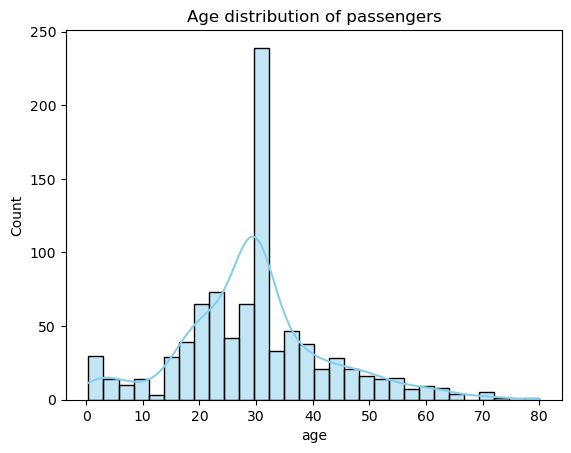

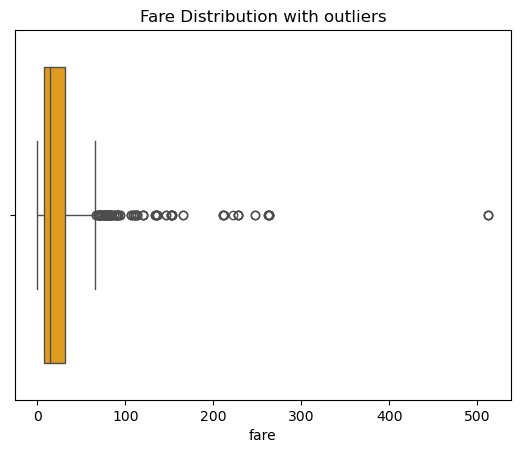

In [7]:
# 6.Univariate analysis -Numerical Features 
nums_cols=df.select_dtypes(include=['float64','int64']).columns
df[nums_cols].describe()

#Histogram :Age
sns.histplot(df['age'],bins=30,kde=True,color='skyblue')
plt.title("Age distribution of passengers")
plt.show()

sns.boxplot(x=df['fare'],color='orange')
plt.title("Fare Distribution with outliers")
plt.show()

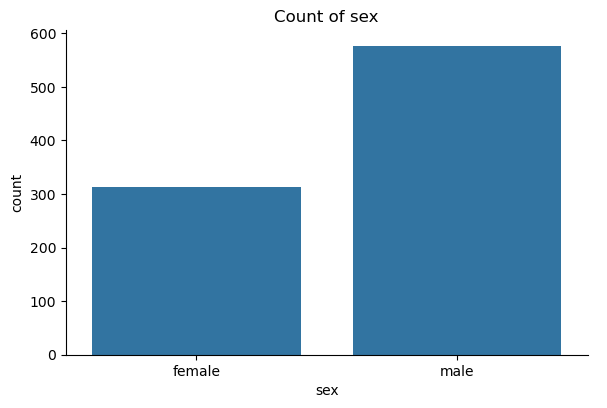

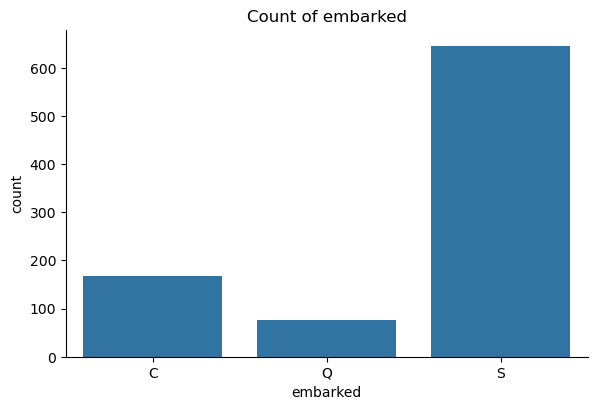

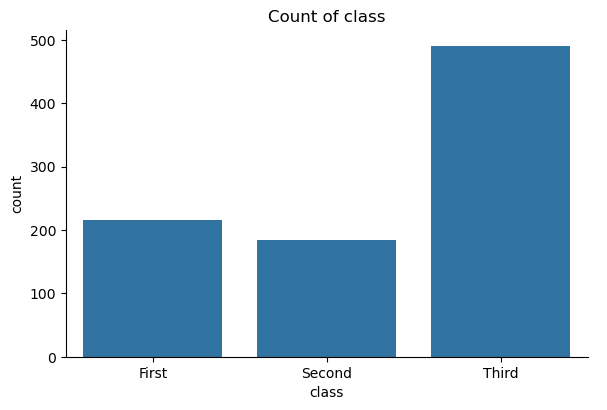

In [11]:
# Univariate Analysis - Categorical Features
cat_cols = df.select_dtypes('category').columns
for col in cat_cols:
    sns.catplot(x=col, data=df, kind='count', height=4, aspect=1.5)
    plt.title(f"Count of {col}")
plt.show()

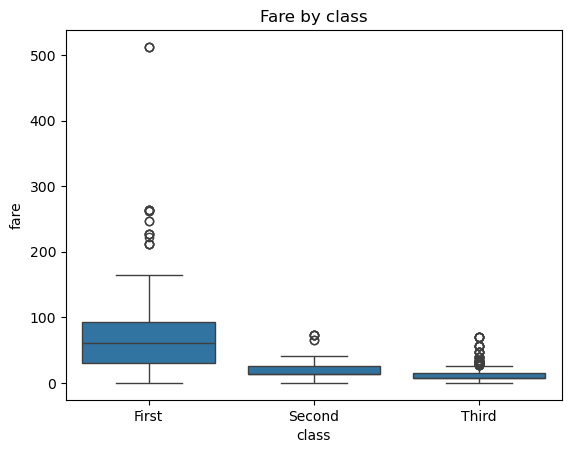

In [12]:
# Bivariate analysis - Numerical vs categorical

sns.boxplot(x='class',y='fare',data=df)
plt.title("Fare by class")
plt.show()

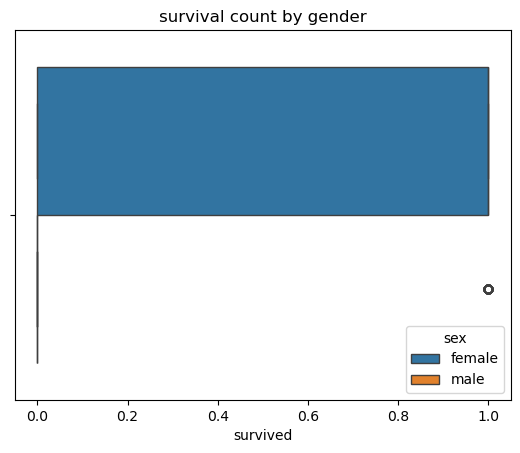

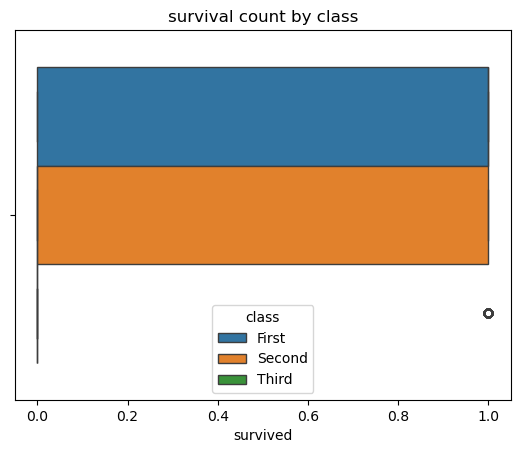

In [13]:
# Bivariate analysis - categorical vs categorical

sns.boxplot(x='survived',hue='sex',data=df)
plt.title("survival count by gender")
plt.show()

sns.boxplot(x='survived',hue='class',data=df)
plt.title("survival count by class")
plt.show()

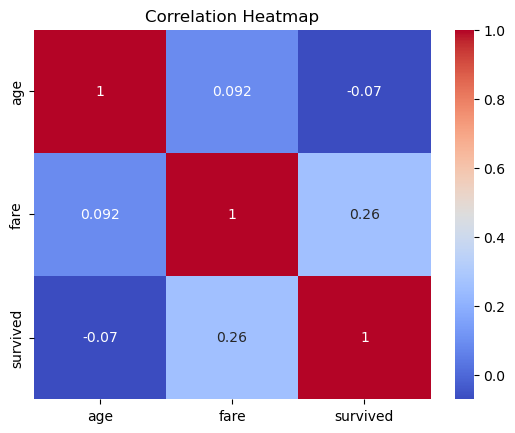

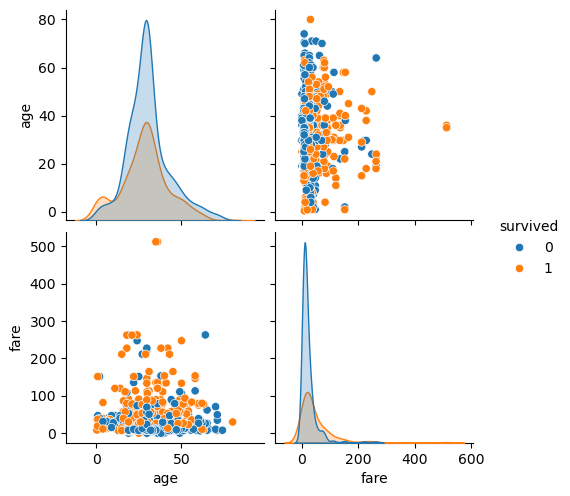

In [14]:
# Correlation and Multivariate Analysis
corr = df[['age', 'fare', 'survived']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
sns.pairplot(df[['age','fare','survived']],hue='survived')
plt.show()

### Insights -

1. Fare has a positive correlation with survival 
2. Age shows a slight negative correlation with survival

Number of outliers in fare: 891
fare after outlier capping


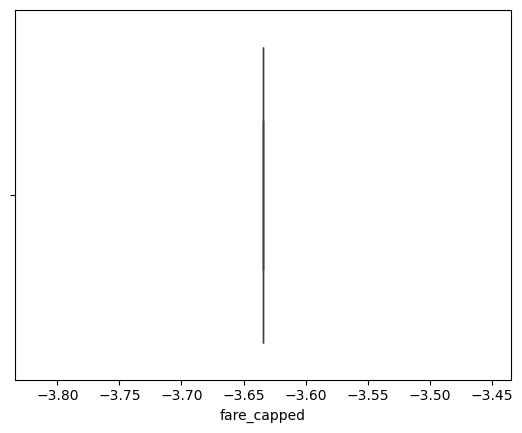

In [15]:
# Outlier Deletion using IQR
Q1=df['fare'].quantile(0.25)
Q3=df['fare'].quantile(0.75)
IQR=Q3-Q1

lower=Q1 - 1.5 * IQR
upper=Q3 - 1.5 * IQR

outliers=df[(df['fare']<lower) | (df['fare']>upper)]
print("Number of outliers in fare:",len(outliers))

#outliers
df['fare_capped']=df['fare'].clip(lower,upper)
sns.boxplot(x=df['fare_capped'])
print("fare after outlier capping")
plt.show()

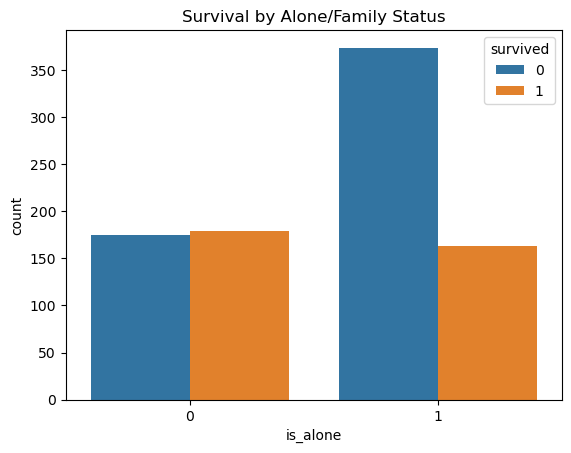

,family_size,is_alone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


In [16]:
# Feature Engineering

# Create new features
df['family_size'] = df['sibsp'] + df['parch'] + 1

df['is_alone'] = (df['family_size'] == 1).astype(int)

sns.countplot(x='is_alone', hue='survived', data=df)
plt.title("Survival by Alone/Family Status")
plt.show()

df[['family_size', 'is_alone']].head()

In [17]:
# Export the cleaned dataa
df.to_csv("titanic_cleaned.csv",index=False)
print("\n Cleaned Titanic data saved as titanic_cleaned.csv")


 Cleaned Titanic data saved as titanic_cleaned.csv


In [18]:
import os
print(os.getcwd())

c:\Users\Sriram reddy\OneDrive\Desktop\tekworks
